<a href="https://colab.research.google.com/github/75somu/FUTURE_ML_03/blob/main/resume_screening_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📄 Task 3 — Resume / Candidate Screening System
### Future Interns ML Project
**Goal:** Automatically screen, score, and rank resumes based on a given job role using NLP + Machine Learning

---
**Pipeline:**
`Resume Text → Clean → Extract Skills → Score vs Job Description → Rank Candidates → Skill Gap Report`



## 📥 CELL 1 — Upload Resume CSV File

In [1]:
# ── Upload CSV File ───────────────────────────────────────
from google.colab import files

print('📂 Please select your Resume.csv file...')
uploaded = files.upload()

if uploaded:
    print(f'\n✅ File uploaded: {list(uploaded.keys())}')
else:
    print('❌ No file uploaded. Please run this cell again.')

📂 Please select your Resume.csv file...


Saving Resume.csv to Resume.csv

✅ File uploaded: ['Resume.csv']


## 📚 CELL 2 — Install spaCy

In [2]:
# ── Install spaCy Model ───────────────────────────────────
!pip install -q spacy
!python -m spacy download en_core_web_sm
print('✅ spaCy installed! Now restart runtime: Runtime → Restart session → then continue from Cell 3')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy installed! Now restart runtime: Runtime → Restart session → then continue from Cell 3


## 📚 CELL 3 — Import All Libraries

In [3]:
# ── All Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import nltk
import spacy
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

nlp = spacy.load('en_core_web_sm')

print('\n✅ All libraries loaded successfully!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



✅ All libraries loaded successfully!


## 📂 CELL 4 — Load Dataset

In [4]:
# ── Load CSV ──────────────────────────────────────────────
csv_candidates = [f for f in os.listdir('.') if f.endswith('.csv')]
print('CSV files found:', csv_candidates)

if not csv_candidates:
    print('\n❌ No CSV found! Go back to Cell 1 and upload Resume.csv')
else:
    CSV_FILE = csv_candidates[0]
    df = pd.read_csv(CSV_FILE)

    # Reset index properly
    df = df.reset_index(drop=True)

    print(f'\n✅ Loaded: {CSV_FILE}')
    print(f'Shape   : {df.shape}')
    print(f'\nColumn Names: {df.columns.tolist()}')
    print(f'\nFirst 2 rows:')
    display(df.head(2))

CSV files found: ['Resume.csv']

✅ Loaded: Resume.csv
Shape   : (2484, 4)

Column Names: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 2 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR


## 🔧 CELL 5 — Fix Column Names

In [5]:
# ── Fix Column Names ──────────────────────────────────────
print('Before:', df.columns.tolist())

col_map = {}
for col in df.columns:
    col_lower = col.lower().strip()
    if 'category' in col_lower or 'label' in col_lower or 'type' in col_lower:
        col_map[col] = 'Category'
    elif 'resume' in col_lower or 'text' in col_lower or 'content' in col_lower:
        col_map[col] = 'Resume'

df.rename(columns=col_map, inplace=True)
print('After :', df.columns.tolist())

# Verify shape is correct
print(f'\nTotal rows    : {len(df)}')
print(f'Total columns : {len(df.columns)}')

# Show category distribution
print(f'\nCategories ({df["Category"].nunique()} total):')
print(df['Category'].value_counts())

Before: ['ID', 'Resume_str', 'Resume_html', 'Category']
After : ['ID', 'Resume', 'Resume', 'Category']

Total rows    : 2484
Total columns : 4

Categories (24 total):
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


## 📊 CELL 6 — Visualize Category Distribution

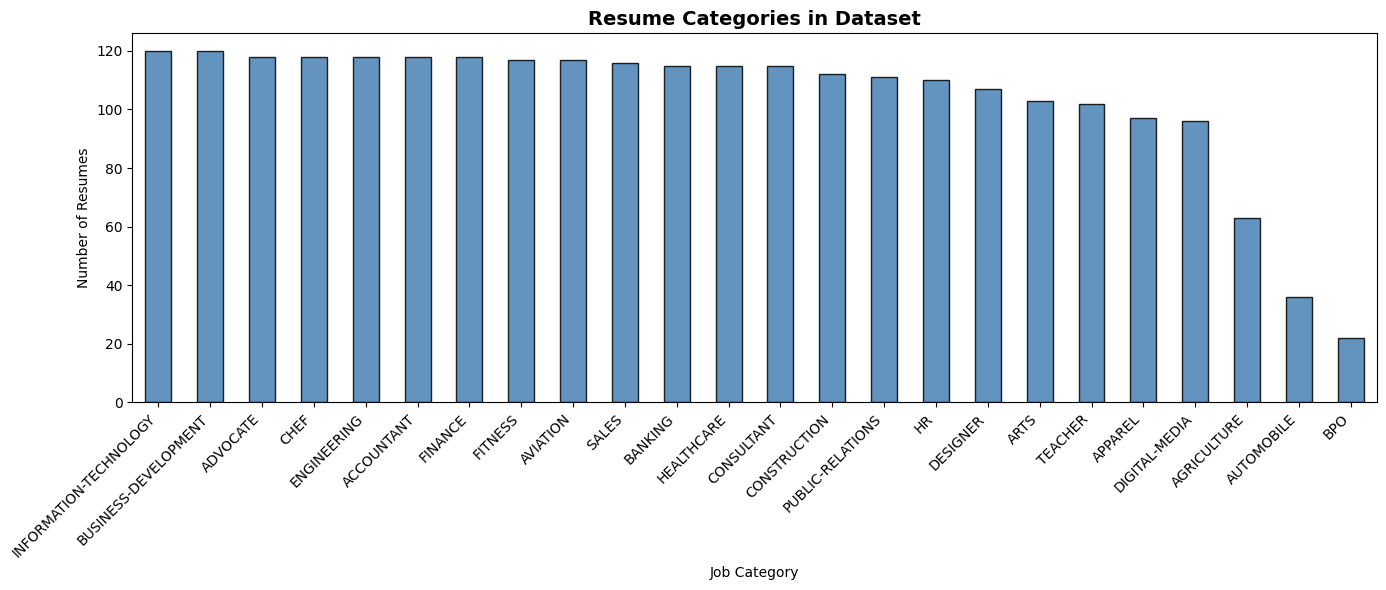

✅ Chart saved!


In [6]:
# ── Category Chart ────────────────────────────────────────
plt.figure(figsize=(14, 6))
df['Category'].value_counts().plot(
    kind='bar', color='steelblue', edgecolor='black', alpha=0.85
)
plt.title('Resume Categories in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Job Category')
plt.ylabel('Number of Resumes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## 🧹 CELL 7 — Text Cleaning

In [7]:
# ── Text Cleaning ─────────────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(tokens)

# Use loop instead of .apply() to avoid index errors
print('🔄 Cleaning resumes... please wait (1-2 mins)...')
clean_texts = []
for i in range(len(df)):
    clean_texts.append(clean_resume(df['Resume'].iloc[i]))

df['clean_resume'] = clean_texts

print('\n--- ORIGINAL (first 200 chars) ---')
print(df['Resume'].iloc[0][:200])
print('\n--- CLEANED (first 200 chars) ---')
print(df['clean_resume'].iloc[0][:200])
print(f'\n✅ Cleaning complete! Total rows: {len(df)}')

🔄 Cleaning resumes... please wait (1-2 mins)...

--- ORIGINAL (first 200 chars) ---
Resume             HR ADMINISTRATOR/MARKETING ASSOCIATE\...
Resume    <div class="fontsize fontface vmargins hmargin...
Name: 0, dtype: object

--- CLEANED (first 200 chars) ---


✅ Cleaning complete! Total rows: 2484


## 🔬 CELL 8 — Skill Extraction

In [8]:
# ── Skills Database ───────────────────────────────────────
SKILLS_DATABASE = [
    'python', 'java', 'javascript', 'sql', 'php', 'r', 'scala',
    'html', 'css', 'react', 'angular', 'nodejs', 'django', 'flask',
    'spring', 'bootstrap', 'jquery', 'wordpress',
    'machine learning', 'deep learning', 'nlp', 'tensorflow', 'pytorch',
    'keras', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit',
    'tableau', 'power bi', 'data analysis', 'data visualization',
    'statistics', 'data mining', 'neural network', 'computer vision',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'git', 'linux',
    'jenkins', 'terraform', 'devops', 'github',
    'mysql', 'postgresql', 'mongodb', 'redis', 'oracle', 'hadoop', 'spark',
    'excel', 'word', 'powerpoint', 'photoshop', 'figma',
    'communication', 'leadership', 'teamwork', 'agile', 'scrum',
    'accounting', 'finance', 'sap', 'marketing', 'seo',
    'android', 'ios', 'flutter', 'swift', 'kotlin',
    'c++', 'golang', 'ruby', 'typescript', 'bash',
]

def extract_skills(text):
    # Use ORIGINAL resume text for skill extraction
    text_lower = str(text).lower()
    return [skill for skill in SKILLS_DATABASE if skill in text_lower]

# Use loop instead of .apply() to avoid index errors
print('🔄 Extracting skills from resumes...')
skill_list = []
for i in range(len(df)):
    skill_list.append(extract_skills(df['Resume'].iloc[i]))

df['skills']      = skill_list
df['skill_count'] = [len(s) for s in skill_list]

print(f'\n✅ Skill extraction complete!')
print(f'Total rows            : {len(df)}')
print(f'Average skills/resume : {sum(df["skill_count"]) / len(df):.1f}')
print(f'Max skills            : {max(df["skill_count"])}')
print(f'Min skills            : {min(df["skill_count"])}')

print('\nSample skill extractions:')
for i in range(3):
    print(f'\n  Resume {i+1} [{df["Category"].iloc[i]}]')
    print(f'  Skills: {df["skills"].iloc[i][:8]}')

🔄 Extracting skills from resumes...

✅ Skill extraction complete!
Total rows            : 2484
Average skills/resume : 1.1
Max skills            : 3
Min skills            : 1

Sample skill extractions:

  Resume 1 [HR]
  Skills: ['r', 'marketing']

  Resume 2 [HR]
  Skills: ['r']

  Resume 3 [HR]
  Skills: ['r']


## 📋 CELL 9 — Define Job Description

In [9]:
# ── Job Descriptions ──────────────────────────────────────
JOB_DESCRIPTIONS = {
    "Data Science": """
        Looking for a Data Scientist with strong skills in Python, machine learning,
        deep learning, TensorFlow, PyTorch, NLP, pandas, numpy, scikit,
        data visualization, matplotlib, tableau, SQL, statistics, data analysis,
        communication, problem solving, and project management.
        Experience with AWS or Azure is a plus. Must know git and agile.
        Knowledge of neural network, computer vision and data mining preferred.
    """,
    "Web Designing": """
        Seeking a Web Developer with HTML, CSS, JavaScript, React, nodejs,
        Python, SQL, mongodb, git, docker, bootstrap, angular,
        communication, teamwork, agile, problem solving.
        Experience with AWS preferred. Knowledge of figma and photoshop a bonus.
    """,
    "Java Developer": """
        Hiring a Java Developer with Java, spring, SQL, Python,
        git, docker, kubernetes, agile, scrum,
        communication, teamwork, and problem solving.
        Experience with aws, jenkins, and mysql preferred.
    """,
    "Python Developer": """
        Looking for Python Developer with Python, django, flask,
        SQL, mongodb, git, docker, linux, pandas, numpy,
        machine learning, scikit, communication, agile, problem solving.
    """,
    "DevOps Engineer": """
        Seeking DevOps Engineer with docker, kubernetes,
        aws, azure, terraform, jenkins, git, linux, bash, python,
        communication, problem solving, and agile.
    """,
    "Testing": """
        QA Test Engineer with manual testing, automation testing,
        python, java, sql, git, agile, scrum, jira,
        communication, problem solving, teamwork.
    """,
    "HR": """
        HR Manager with communication, leadership, teamwork,
        excel, word, agile, problem solving, sap, finance, accounting.
    """,
    "Mechanical Engineer": """
        Mechanical Engineer with matlab, python, excel, statistics,
        communication, leadership, problem solving, teamwork, agile.
    """,
    "Sales": """
        Sales Executive with communication, leadership, teamwork,
        excel, word, powerpoint, marketing, seo, finance, problem solving.
    """,
    "Accountant": """
        Accountant with accounting, finance, excel, sap, sql,
        communication, teamwork, problem solving, word, powerpoint.
    """
}

# Show available categories
print('📋 Categories in your dataset:')
for cat in sorted(df['Category'].unique()):
    print(f'   • {cat}')

print('\n📋 Available job roles:')
for job in JOB_DESCRIPTIONS.keys():
    print(f'   • {job}')

📋 Categories in your dataset:
   • ACCOUNTANT
   • ADVOCATE
   • AGRICULTURE
   • APPAREL
   • ARTS
   • AUTOMOBILE
   • AVIATION
   • BANKING
   • BPO
   • BUSINESS-DEVELOPMENT
   • CHEF
   • CONSTRUCTION
   • CONSULTANT
   • DESIGNER
   • DIGITAL-MEDIA
   • ENGINEERING
   • FINANCE
   • FITNESS
   • HEALTHCARE
   • HR
   • INFORMATION-TECHNOLOGY
   • PUBLIC-RELATIONS
   • SALES
   • TEACHER

📋 Available job roles:
   • Data Science
   • Web Designing
   • Java Developer
   • Python Developer
   • DevOps Engineer
   • Testing
   • HR
   • Mechanical Engineer
   • Sales
   • Accountant


In [10]:
# ── SELECT JOB ROLE ───────────────────────────────────────
# 👇 Change this to match a category from your dataset
SELECTED_JOB = "Data Science"

# Auto-create description if not in list
if SELECTED_JOB not in JOB_DESCRIPTIONS:
    JOB_DESCRIPTIONS[SELECTED_JOB] = f"""
        Looking for a {SELECTED_JOB} professional with strong technical skills,
        python, sql, communication, teamwork, problem solving, leadership,
        project management, agile, git, and relevant domain expertise.
    """
    print(f'⚠️  Created generic description for: {SELECTED_JOB}')

JOB_TEXT             = JOB_DESCRIPTIONS[SELECTED_JOB]
JOB_REQUIRED_SKILLS  = extract_skills(JOB_TEXT)

print(f'\n📋 Screening for: {SELECTED_JOB}')
print(f'Required Skills ({len(JOB_REQUIRED_SKILLS)} total):')
for skill in JOB_REQUIRED_SKILLS:
    print(f'   • {skill}')


📋 Screening for: Data Science
Required Skills (24 total):
   • python
   • sql
   • r
   • machine learning
   • deep learning
   • nlp
   • tensorflow
   • pytorch
   • pandas
   • numpy
   • matplotlib
   • scikit
   • tableau
   • data analysis
   • data visualization
   • statistics
   • data mining
   • neural network
   • computer vision
   • aws
   • azure
   • git
   • communication
   • agile


## 📊 CELL 10 — TF-IDF Similarity Scoring

In [11]:
# ── TF-IDF Cosine Similarity ──────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

# Build text list using loop — most reliable method
resume_list = []
for i in range(len(df)):
    resume_list.append(str(df['Resume'].iloc[i]))

original_texts = [JOB_TEXT] + resume_list

print(f'Total texts to process : {len(original_texts)}')
print(f'Total resumes          : {len(resume_list)}')
print(f'Job text length        : {len(JOB_TEXT)} chars')

# Vectorize
tfidf_matrix  = tfidf.fit_transform(original_texts)
job_vector    = tfidf_matrix[0]
resume_matrix = tfidf_matrix[1:]

# Calculate similarity scores
similarity_scores = cosine_similarity(job_vector, resume_matrix)[0]

print(f'\nSimilarity scores shape : {similarity_scores.shape}')
print(f'DataFrame rows          : {len(df)}')

# Assign scores using loop to avoid index errors
sim_score_list = []
sim_pct_list   = []
for i in range(len(similarity_scores)):
    sim_score_list.append(float(similarity_scores[i]))
    sim_pct_list.append(round(float(similarity_scores[i]) * 100, 2))

df['similarity_score'] = sim_score_list
df['similarity_pct']   = sim_pct_list

print(f'\n✅ Similarity scoring complete!')
print(f'Score range : {min(sim_pct_list):.1f}% → {max(sim_pct_list):.1f}%')
print(f'Average     : {sum(sim_pct_list)/len(sim_pct_list):.1f}%')

Total texts to process : 2485
Total resumes          : 2484
Job text length        : 460 chars

Similarity scores shape : (2484,)
DataFrame rows          : 2484

✅ Similarity scoring complete!
Score range : 0.0% → 21.3%
Average     : 0.4%


## 🎯 CELL 11 — Skill Match Scoring

In [12]:
# ── Skill Match Scoring ───────────────────────────────────
skill_match_list  = []
matched_list      = []
missing_list      = []
matched_count_list = []
missing_count_list = []

for i in range(len(df)):
    resume_skills = df['skills'].iloc[i]
    matched = sorted(set(resume_skills) & set(JOB_REQUIRED_SKILLS))
    missing = sorted(set(JOB_REQUIRED_SKILLS) - set(resume_skills))

    if JOB_REQUIRED_SKILLS:
        score = round(len(matched) / len(JOB_REQUIRED_SKILLS) * 100, 2)
    else:
        score = 0

    skill_match_list.append(score)
    matched_list.append(matched)
    missing_list.append(missing)
    matched_count_list.append(len(matched))
    missing_count_list.append(len(missing))

df['skill_match_pct'] = skill_match_list
df['matched_skills']  = matched_list
df['missing_skills']  = missing_list
df['matched_count']   = matched_count_list
df['missing_count']   = missing_count_list

print('✅ Skill matching complete!')
print(f'Average skill match : {sum(skill_match_list)/len(skill_match_list):.1f}%')
print(f'Best skill match    : {max(skill_match_list):.1f}%')
print(f'Required skills     : {len(JOB_REQUIRED_SKILLS)}')

✅ Skill matching complete!
Average skill match : 4.3%
Best skill match    : 12.5%
Required skills     : 24


## 🏆 CELL 12 — Final Score and Ranking

In [13]:
# ── Final Score = 60% Skill Match + 40% Similarity ────────
final_score_list = []
for i in range(len(df)):
    score = round(
        (df['skill_match_pct'].iloc[i] * 0.60) +
        (df['similarity_pct'].iloc[i]  * 0.40), 2
    )
    final_score_list.append(score)

df['final_score'] = final_score_list

# Sort by score
df_ranked = df.sort_values('final_score', ascending=False)
df_ranked = df_ranked.reset_index(drop=True)
df_ranked['rank'] = df_ranked.index + 1

# Display top 10
print(f'\n🏆 TOP 10 CANDIDATES FOR: {SELECTED_JOB}')
print('=' * 72)
print(f'{"Rank":<6} {"Category":<28} {"Skill Match":<14} {"Similarity":<13} {"Score"}')
print('-' * 72)
for i in range(min(10, len(df_ranked))):
    row = df_ranked.iloc[i]
    print(f"{i+1:<6} {str(row['Category']):<28} {row['skill_match_pct']:<14.1f} {row['similarity_pct']:<13.1f} {row['final_score']:.1f}")
print('=' * 72)
print(f'Total screened    : {len(df)}')
print(f'Strong fit  (>60) : {len([s for s in final_score_list if s > 60])}')
print(f'Shortlisted (>50) : {len([s for s in final_score_list if s > 50])}')


🏆 TOP 10 CANDIDATES FOR: Data Science
Rank   Category                     Skill Match    Similarity    Score
------------------------------------------------------------------------
1      AUTOMOBILE                   4.2            21.3          11.0
2      AUTOMOBILE                   4.2            20.9          10.8
3      DESIGNER                     4.2            20.6          10.7
4      APPAREL                      4.2            20.6          10.7
5      DIGITAL-MEDIA                4.2            18.2          9.8
6      HEALTHCARE                   4.2            18.0          9.7
7      BANKING                      8.3            10.5          9.2
8      AVIATION                     4.2            16.3          9.0
9      HEALTHCARE                   4.2            15.0          8.5
10     INFORMATION-TECHNOLOGY       8.3            7.9           8.2
Total screened    : 2484
Strong fit  (>60) : 0
Shortlisted (>50) : 0


## 📈 CELL 13 — Visualize Results

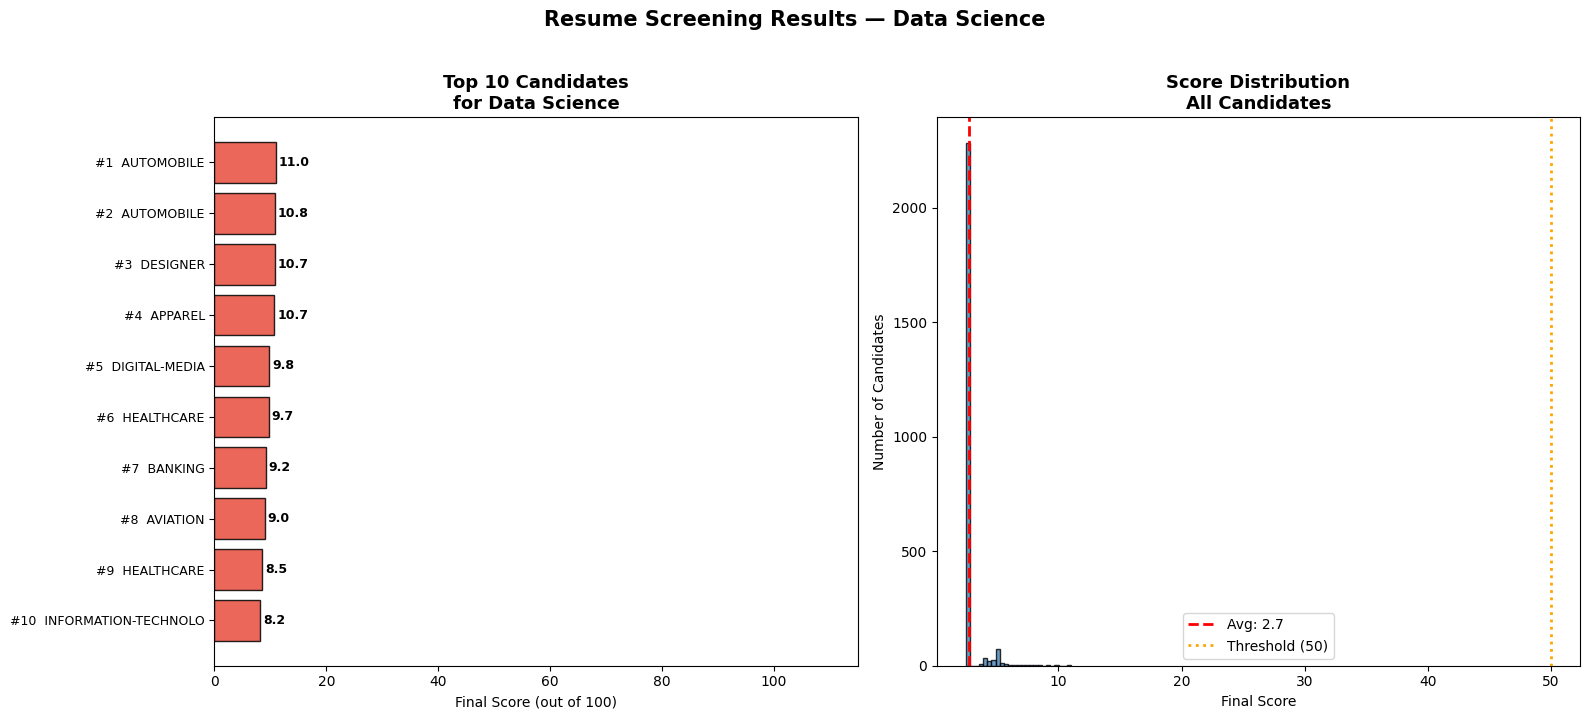

✅ Chart saved as screening_results.png


In [14]:
# ── Top 10 + Score Distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top10  = df_ranked.head(10)
colors = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 40 else '#e74c3c'
          for s in top10['final_score']]

bars = axes[0].barh(
    range(len(top10)), top10['final_score'],
    color=colors, edgecolor='black', alpha=0.85
)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(
    [f"#{i+1}  {str(top10['Category'].iloc[i])[:20]}" for i in range(len(top10))],
    fontsize=9
)
for i, bar in enumerate(bars):
    axes[0].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        f"{top10['final_score'].iloc[i]:.1f}",
        va='center', fontsize=9, fontweight='bold'
    )
axes[0].set_xlabel('Final Score (out of 100)')
axes[0].set_title(f'Top 10 Candidates\nfor {SELECTED_JOB}',
                   fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 115)

axes[1].hist(df['final_score'], bins=25,
             color='steelblue', edgecolor='black', alpha=0.8)
avg_score = sum(final_score_list) / len(final_score_list)
axes[1].axvline(avg_score, color='red', linestyle='--',
                linewidth=2, label=f'Avg: {avg_score:.1f}')
axes[1].axvline(50, color='orange', linestyle=':',
                linewidth=2, label='Threshold (50)')
axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('Number of Candidates')
axes[1].set_title('Score Distribution\nAll Candidates',
                   fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle(f'Resume Screening Results — {SELECTED_JOB}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('screening_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as screening_results.png')

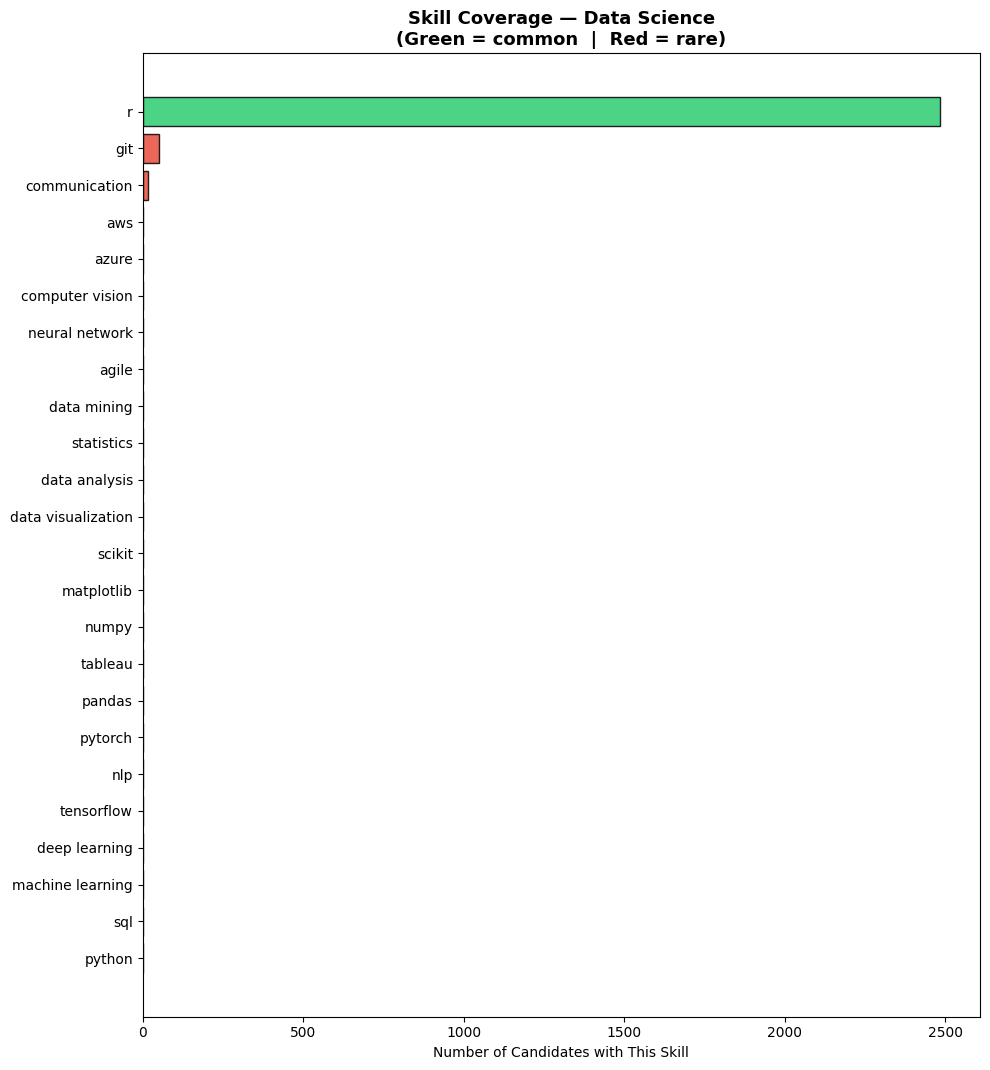

✅ Skill coverage chart saved!


In [15]:
# ── Skill Coverage Chart ──────────────────────────────────
skill_coverage = {}
for skill in JOB_REQUIRED_SKILLS:
    count = 0
    for i in range(len(df)):
        if skill in df['skills'].iloc[i]:
            count += 1
    skill_coverage[skill] = count

skill_df = pd.DataFrame(
    list(skill_coverage.items()),
    columns=['Skill', 'Count']
).sort_values('Count', ascending=True)

plt.figure(figsize=(10, max(5, len(JOB_REQUIRED_SKILLS) * 0.45)))
bar_colors = ['#2ecc71' if v > len(df)*0.3 else '#e74c3c'
              for v in skill_df['Count']]
plt.barh(skill_df['Skill'], skill_df['Count'],
         color=bar_colors, edgecolor='black', alpha=0.85)
plt.xlabel('Number of Candidates with This Skill')
plt.title(f'Skill Coverage — {SELECTED_JOB}\n(Green = common  |  Red = rare)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('skill_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Skill coverage chart saved!')

## 🔍 CELL 14 — Skill Gap Report

In [16]:
# ── Detailed Candidate Report ─────────────────────────────
def print_candidate_report(row, rank):
    print(f"\n{'='*62}")
    print(f"  RANK #{rank}  |  Category: {row['Category']}")
    print(f"{'='*62}")
    print(f"  Final Score     : {row['final_score']:.1f} / 100")
    print(f"  Skill Match     : {row['skill_match_pct']:.1f}%  ({row['matched_count']}/{len(JOB_REQUIRED_SKILLS)} skills)")
    print(f"  Text Similarity : {row['similarity_pct']:.1f}%")

    if row['final_score'] >= 60:
        verdict = '✅ STRONG FIT — Recommended for interview'
    elif row['final_score'] >= 40:
        verdict = '🟡 MODERATE FIT — Consider with caution'
    else:
        verdict = '❌ WEAK FIT — Does not meet requirements'
    print(f"\n  Verdict : {verdict}")
    print(f"\n  ✅ Matched Skills : {', '.join(row['matched_skills']) if row['matched_skills'] else 'None'}")
    print(f"\n  ❌ Missing Skills : {', '.join(row['missing_skills']) if row['missing_skills'] else 'None — Perfect match!'}")
    print(f"{'='*62}")

print(f'\n📊 DETAILED SCREENING REPORT')
print(f'Job Role          : {SELECTED_JOB}')
print(f'Required Skills   : {len(JOB_REQUIRED_SKILLS)}')
print(f'Total Screened    : {len(df)}')
print(f'Shortlisted (>50) : {len([s for s in final_score_list if s > 50])}')

print(f'\n--- TOP 5 CANDIDATE REPORTS ---')
for i in range(min(5, len(df_ranked))):
    print_candidate_report(df_ranked.iloc[i], i + 1)


📊 DETAILED SCREENING REPORT
Job Role          : Data Science
Required Skills   : 24
Total Screened    : 2484
Shortlisted (>50) : 0

--- TOP 5 CANDIDATE REPORTS ---

  RANK #1  |  Category: AUTOMOBILE
  Final Score     : 11.0 / 100
  Skill Match     : 4.2%  (1/24 skills)
  Text Similarity : 21.3%

  Verdict : ❌ WEAK FIT — Does not meet requirements

  ✅ Matched Skills : r

  ❌ Missing Skills : agile, aws, azure, communication, computer vision, data analysis, data mining, data visualization, deep learning, git, machine learning, matplotlib, neural network, nlp, numpy, pandas, python, pytorch, scikit, sql, statistics, tableau, tensorflow

  RANK #2  |  Category: AUTOMOBILE
  Final Score     : 10.8 / 100
  Skill Match     : 4.2%  (1/24 skills)
  Text Similarity : 20.9%

  Verdict : ❌ WEAK FIT — Does not meet requirements

  ✅ Matched Skills : r

  ❌ Missing Skills : agile, aws, azure, communication, computer vision, data analysis, data mining, data visualization, deep learning, git, machi

## 💾 CELL 15 — Export Results to CSV

In [17]:
# ── Save Results ──────────────────────────────────────────
output_cols = [
    'rank', 'Category', 'final_score',
    'skill_match_pct', 'similarity_pct',
    'matched_count', 'missing_count',
    'matched_skills', 'missing_skills'
]

df_ranked[output_cols].to_csv('screening_results.csv', index=False)

print('✅ Results saved to screening_results.csv')
print(f'\n📊 FINAL SUMMARY')
print(f'Job Role         : {SELECTED_JOB}')
print(f'Total Screened   : {len(df)}')
print(f'Average Score    : {sum(final_score_list)/len(final_score_list):.1f}')
print(f'Highest Score    : {max(final_score_list):.1f}')
print(f'Lowest Score     : {min(final_score_list):.1f}')
print(f'Strong Fit (>60) : {len([s for s in final_score_list if s > 60])} candidates')
print(f'Moderate (40-60) : {len([s for s in final_score_list if 40 <= s <= 60])} candidates')
print(f'Weak Fit (<40)   : {len([s for s in final_score_list if s < 40])} candidates')

✅ Results saved to screening_results.csv

📊 FINAL SUMMARY
Job Role         : Data Science
Total Screened   : 2484
Average Score    : 2.7
Highest Score    : 11.0
Lowest Score     : 2.5
Strong Fit (>60) : 0 candidates
Moderate (40-60) : 0 candidates
Weak Fit (<40)   : 2484 candidates


## 📥 CELL 16 — Download All Files

In [18]:
# ── Download All Output Files ─────────────────────────────
from google.colab import files

download_list = [
    'category_distribution.png',
    'screening_results.png',
    'skill_coverage.png',
    'screening_results.csv'
]

for file in download_list:
    try:
        files.download(file)
        print(f'✅ Downloaded: {file}')
    except Exception as e:
        print(f'⚠️  Could not download {file}: {e}')

print('\n🎉 Task 3 Complete! Upload everything to GitHub.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: category_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: skill_coverage.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: screening_results.csv

🎉 Task 3 Complete! Upload everything to GitHub.


---
## ✅ Project Completion Summary

| Cell | Task | Status |
|------|------|--------|
| 1 | Resume CSV uploaded | ✅ |
| 2 | spaCy installed | ✅ |
| 3 | Libraries imported | ✅ |
| 4 | Data loaded | ✅ |
| 5 | Columns fixed | ✅ |
| 6 | Category chart created | ✅ |
| 7 | Text cleaned | ✅ |
| 8 | Skills extracted | ✅ |
| 9 | Job description selected | ✅ |
| 10 | TF-IDF similarity scored | ✅ |
| 11 | Skill match scored | ✅ |
| 12 | Candidates ranked | ✅ |
| 13 | Results visualized | ✅ |
| 14 | Skill gap report generated | ✅ |
| 15 | Results exported to CSV | ✅ |
| 16 | Files downloaded to PC | ✅ |

---
### 🚀 Built for Future Interns — Task 3
**Tech Stack:** Python · scikit-learn · NLTK · spaCy · pandas · matplotlib · seaborn